In [1]:
import json
import matplotlib.pyplot as plt

from collections import defaultdict

In [2]:
folder = "ablate_by_difficulty_pft_500"
pft_suffix = "_pft_500"

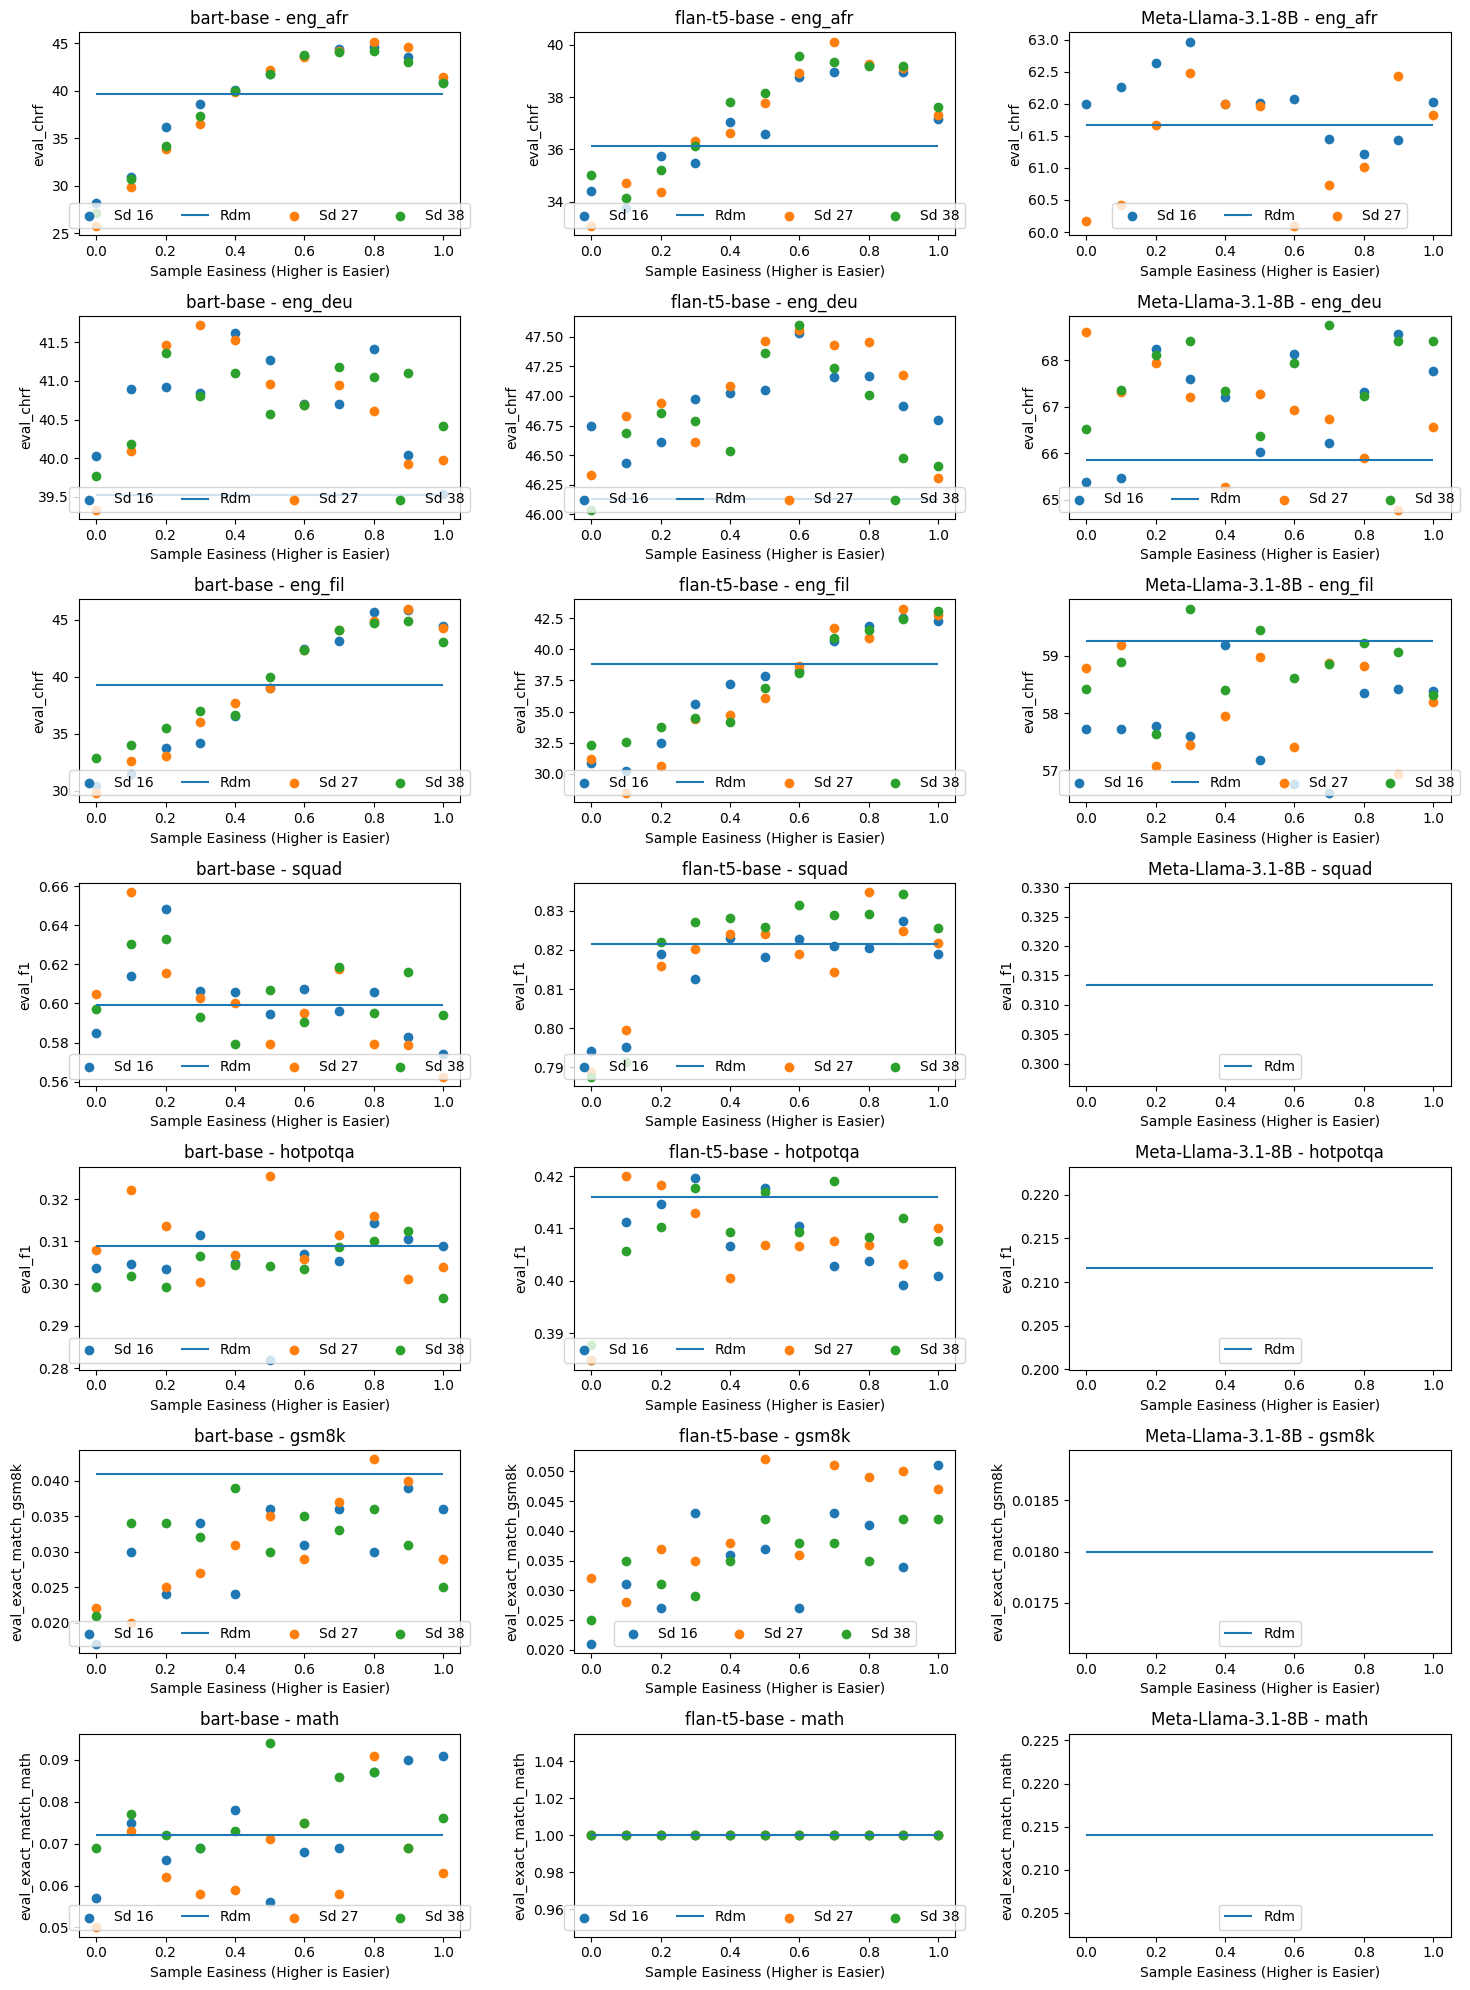

In [3]:
dataset_metric_pairs = [
    ("eng_afr", "eval_chrf"),
    ("eng_deu", "eval_chrf"),
    ("eng_fil", "eval_chrf"),
    ("squad", "eval_f1"),
    ("hotpotqa", "eval_f1"),
    ("gsm8k", "eval_exact_match_gsm8k"),
    ("math", "eval_exact_match_math"),
]

fig, ax = plt.subplots(7, 3, figsize=(15, 20))


def plot_on_fig(
    x: list[float] | None,
    y: list[float] | float,
    row_idx: int,
    col_idx: int,
    plot_title: str,
    line_label: str,
    y_label: str,
):
    x_label = (
        "Sample Easiness (Higher is Easier)"
        if "by_difficulty" in folder
        else "Sample Confidence (Higher is More Confident)"
    )
    if (x is None) and isinstance(y, float):
        ax[row_idx, col_idx].hlines(y=y, xmin=0, xmax=1, label=line_label)
    else:
        ax[row_idx, col_idx].scatter(x, y, label=line_label)

    ax[row_idx, col_idx].set_title(plot_title)
    ax[row_idx, col_idx].set_xlabel(x_label)
    ax[row_idx, col_idx].set_ylabel(y_label)
    ax[row_idx, col_idx].legend(loc="lower center", ncol=4)


for row_idx, (dataset, eval_metric) in enumerate(dataset_metric_pairs):
    for col_idx, model in enumerate(["bart-base", "flan-t5-base", "Meta-Llama-3.1-8B"]):
        title = f"{model} - {dataset}"
        for seed in [16, 27, 38]:
            for suffix in [""]:  # , "_degenerate"]:
                try:
                    # if dataset in ["math", "gsm8k"]:
                    #     suffix = f"_rerun_rougel{suffix}"
                    if "ablate_by_confidence" in folder:
                        suffix += "_confidence"
                    results = json.load(
                        open(
                            f"results/{folder}/{dataset}_eps_10_{model}_seed_{seed}{suffix}{pft_suffix}_ablation.json"
                        )
                    )
                    x = [float(x) for x in results.keys()]
                    y = [results[k][eval_metric] for k in results.keys()]
                    plot_label = f"Sd {seed}"
                    if suffix == "_degenerate":
                        plot_label = f"Dgn {seed}"
                    plot_on_fig(
                        x,
                        y,
                        row_idx,
                        col_idx,
                        plot_title=title,
                        line_label=plot_label,
                        y_label=eval_metric,
                    )
                except FileNotFoundError:
                    continue

            # Add random sampling
            try:
                results = json.load(
                    open(
                        f"results/ablate_random/{dataset}_eps_10_{model}_seed_{seed}_random_ablation.json"
                    )
                )
                y = results["random"][eval_metric]
                plot_on_fig(
                    None,
                    y,
                    row_idx,
                    col_idx,
                    plot_title=title,
                    line_label="Rdm",
                    y_label=eval_metric,
                )
            except FileNotFoundError:
                continue
fig.tight_layout()